# House Price Prediction using Machine Learning

## Objective
Build a machine learning model to predict house prices based on various house features.

---

## Workflow

1. Import Libraries
2. Load Dataset
3. Understand Dataset
4. Exploratory Data Analysis
5. Data Cleaning
6. Feature Engineering
7. Train Machine Learning Models
8. Evaluate Performance
9. Save Best Model

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split

In [2]:
# Load dataset
df = pd.read_csv("../data/train (1).csv")

# Display first five rows
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
print("Rows and Columns:", df.shape)


Rows and Columns: (1460, 81)


In [4]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [6]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [7]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Optional: Better plot appearance
plt.style.use("ggplot")

In [9]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1460, 81)


In [10]:
df.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [11]:
df.dtypes

Id                 int64
MSSubClass         int64
MSZoning             str
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType             str
SaleCondition        str
SalePrice          int64
Length: 81, dtype: object

In [12]:
numerical_features = df.select_dtypes(include=['int64', 'float64'])

categorical_features = df.select_dtypes(include=['object'])

print("Numerical Features:", numerical_features.shape[1])
print("Categorical Features:", categorical_features.shape[1])

Numerical Features: 38
Categorical Features: 43


C:\Users\Asus\AppData\Local\Temp\ipykernel_1008\40444478.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=['object'])


In [13]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

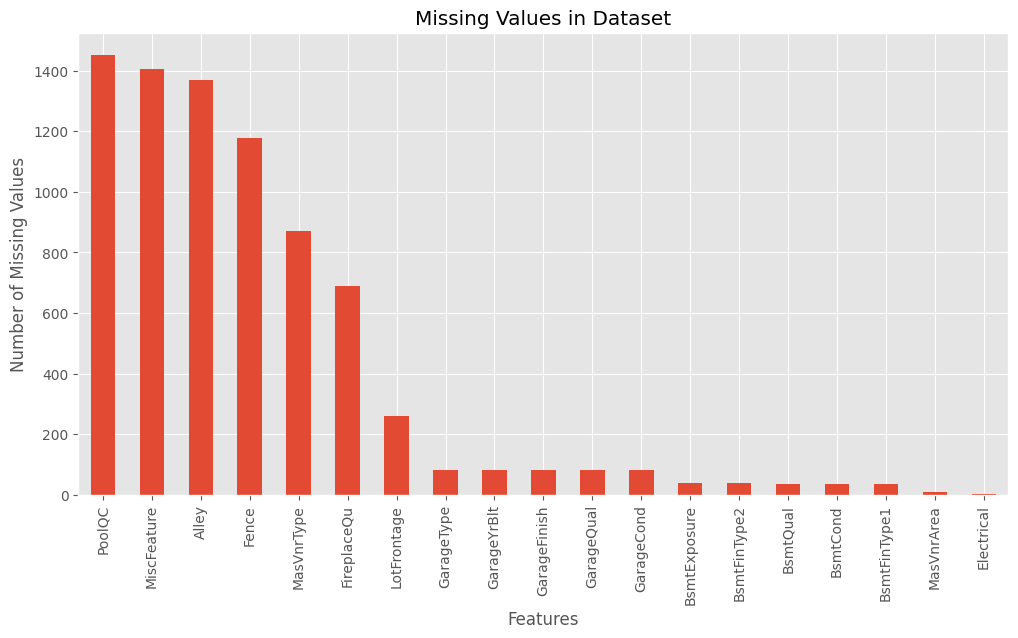

In [14]:
missing.sort_values(ascending=False).plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Missing Values in Dataset")

plt.xlabel("Features")

plt.ylabel("Number of Missing Values")

plt.show()

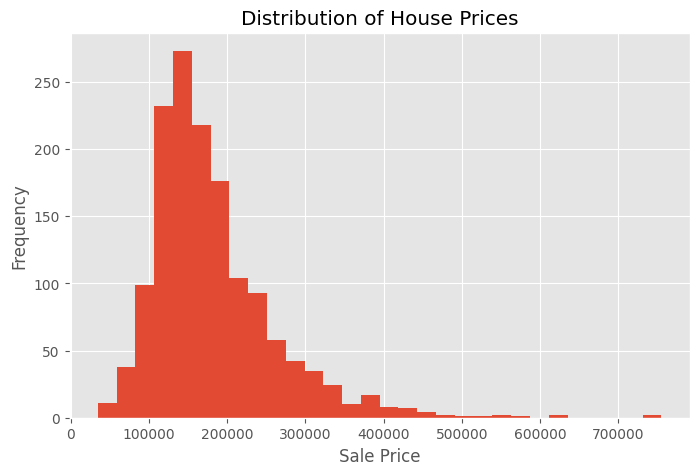

In [15]:
plt.figure(figsize=(8,5))

plt.hist(df["SalePrice"], bins=30)

plt.title("Distribution of House Prices")

plt.xlabel("Sale Price")

plt.ylabel("Frequency")

plt.show()

In [16]:
correlation = df.corr(numeric_only=True)

correlation

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,1.000000,0.011156,-0.010601,-0.033226,-0.028365,0.012609,-0.012713,-0.021998,-0.050298,-0.005024,...,-0.029643,-0.000477,0.002889,-0.046635,0.001330,0.057044,-0.006242,0.021172,0.000712,-0.021917
MSSubClass,0.011156,1.000000,-0.386347,-0.139781,0.032628,-0.059316,0.027850,0.040581,0.022936,-0.069836,...,-0.012579,-0.006100,-0.012037,-0.043825,-0.026030,0.008283,-0.007683,-0.013585,-0.021407,-0.084284
LotFrontage,-0.010601,-0.386347,1.000000,0.426095,0.251646,-0.059213,0.123349,0.088866,0.193458,0.233633,...,0.088521,0.151972,0.010700,0.070029,0.041383,0.206167,0.003368,0.011200,0.007450,0.351799
LotArea,-0.033226,-0.139781,0.426095,1.000000,0.105806,-0.005636,0.014228,0.013788,0.104160,0.214103,...,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.263843
OverallQual,-0.028365,0.032628,0.251646,0.105806,1.000000,-0.091932,0.572323,0.550684,0.411876,0.239666,...,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347,0.790982
OverallCond,0.012609,-0.059316,-0.059213,-0.005636,-0.091932,1.000000,-0.375983,0.073741,-0.128101,-0.046231,...,-0.003334,-0.032589,0.070356,0.025504,0.054811,-0.001985,0.068777,-0.003511,0.043950,-0.077856
YearBuilt,-0.012713,0.027850,0.123349,0.014228,0.572323,-0.375983,1.000000,0.592855,0.315707,0.249503,...,0.224880,0.188686,-0.387268,0.031355,-0.050364,0.004950,-0.034383,0.012398,-0.013618,0.522897
YearRemodAdd,-0.021998,0.040581,0.088866,0.013788,0.550684,0.073741,0.592855,1.000000,0.179618,0.128451,...,0.205726,0.226298,-0.193919,0.045286,-0.038740,0.005829,-0.010286,0.021490,0.035743,0.507101
MasVnrArea,-0.050298,0.022936,0.193458,0.104160,0.411876,-0.128101,0.315707,0.179618,1.000000,0.264736,...,0.159718,0.125703,-0.110204,0.018796,0.061466,0.011723,-0.029815,-0.005965,-0.008201,0.477493
BsmtFinSF1,-0.005024,-0.069836,0.233633,0.214103,0.239666,-0.046231,0.249503,0.128451,0.264736,1.000000,...,0.204306,0.111761,-0.102303,0.026451,0.062021,0.140491,0.003571,-0.015727,0.014359,0.386420


In [17]:
correlation["SalePrice"].sort_values(ascending=False).head(15)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

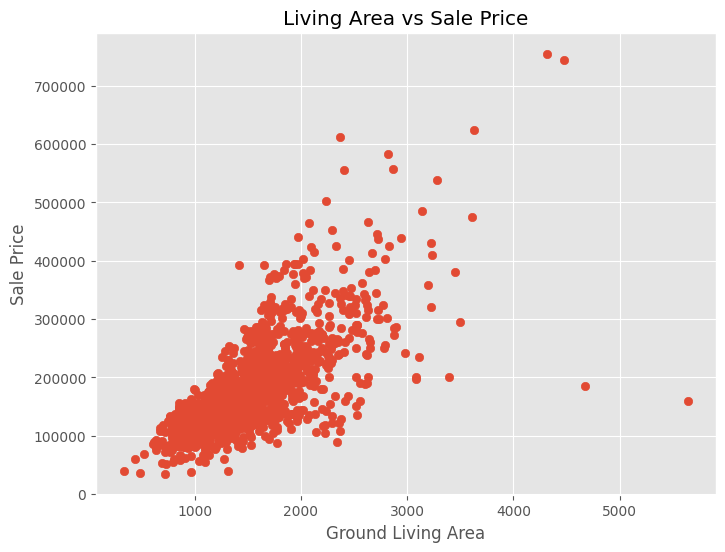

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(df["GrLivArea"], df["SalePrice"])

plt.xlabel("Ground Living Area")

plt.ylabel("Sale Price")

plt.title("Living Area vs Sale Price")

plt.show()

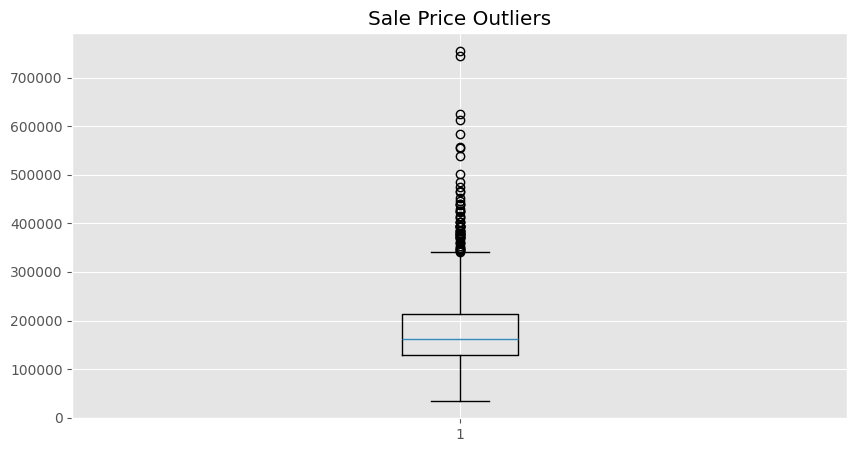

In [19]:
plt.figure(figsize=(10,5))

plt.boxplot(df["SalePrice"])

plt.title("Sale Price Outliers")

plt.show()

In [20]:
# Create a working copy
df_clean = df.copy()

print("Copy created successfully!")


Copy created successfully!


In [21]:


duplicates = df_clean.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [22]:
missing_values = df_clean.isnull().sum()

missing_values = missing_values[missing_values > 0]

missing_values.sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [23]:
numerical_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns

categorical_cols = df_clean.select_dtypes(include=["object"]).columns

print("Numerical Features:", len(numerical_cols))
print("Categorical Features:", len(categorical_cols))

Numerical Features: 38
Categorical Features: 43


C:\Users\Asus\AppData\Local\Temp\ipykernel_1008\214158433.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_clean.select_dtypes(include=["object"]).columns


In [24]:
for column in numerical_cols:
    df_clean[column] = df_clean[column].fillna(df_clean[column].median())

In [25]:
for column in categorical_cols:
    df_clean[column] = df_clean[column].fillna(df_clean[column].mode()[0])

In [26]:
df_clean.isnull().sum().sum()


np.int64(0)

In [27]:
df_clean["TotalLivingArea"] = (
    df_clean["GrLivArea"] +
    df_clean["TotalBsmtSF"]
)

In [28]:
df_clean["HouseAge"] = 2025 - df_clean["YearBuilt"]

In [29]:
df_clean = df_clean[
    df_clean["GrLivArea"] < 4000
]


In [30]:
print("Original Shape:", df.shape)

print("Cleaned Shape:", df_clean.shape)

Original Shape: (1460, 81)
Cleaned Shape: (1456, 83)


In [31]:
df_clean.to_csv("../data/cleaned_house_data.csv", index=False)

print("Cleaned dataset saved successfully!")


Cleaned dataset saved successfully!


In [32]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [33]:
label_encoder = LabelEncoder()

for column in categorical_cols:
    df_clean[column] = label_encoder.fit_transform(df_clean[column])

In [34]:
X = df_clean.drop("SalePrice", axis=1)

y = df_clean["SalePrice"]

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [36]:
print("Training Features:", X_train.shape)

print("Testing Features:", X_test.shape)

print("Training Labels:", y_train.shape)

print("Testing Labels:", y_test.shape)

Training Features: (1164, 82)
Testing Features: (292, 82)
Training Labels: (1164,)
Testing Labels: (292,)


In [37]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](82,)","[ -2.16, -82.3 ,-2129.72,..., 4477.78, 22.59, -112.33]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](82,)","['Id','MSSubClass','MSZoning',...,'SaleCondition','TotalLivingArea', 'HouseAge']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.597e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,82
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(78)


In [38]:
linear_predictions = linear_model.predict(X_test)

In [39]:
print("Linear Regression Results")

print("MAE:",
      mean_absolute_error(y_test, linear_predictions))

print("RMSE:",
      np.sqrt(mean_squared_error(
          y_test,
          linear_predictions
      )))

print("R2 Score:",
      r2_score(
          y_test,
          linear_predictions
      ))

Linear Regression Results
MAE: 18296.642607948244
RMSE: 24563.588463103933
R2 Score: 0.8850377694558602


In [40]:
decision_tree = DecisionTreeRegressor(
    random_state=42
)

decision_tree.fit(
    X_train,
    y_train
)

decision_predictions = decision_tree.predict(
    X_test
)

In [41]:
print("Decision Tree Results")

print("MAE:",
      mean_absolute_error(
          y_test,
          decision_predictions
      ))

print("RMSE:",
      np.sqrt(mean_squared_error(
          y_test,
          decision_predictions
      )))

print("R2 Score:",
      r2_score(
          y_test,
          decision_predictions
      ))

Decision Tree Results
MAE: 26837.801369863013
RMSE: 40845.692522263445
R2 Score: 0.682119356282632


In [42]:
random_forest = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

random_forest.fit(
    X_train,
    y_train
)

forest_predictions = random_forest.predict(
    X_test
)


In [43]:
print("Random Forest Results")

print("MAE:",
      mean_absolute_error(
          y_test,
          forest_predictions
      ))

print("RMSE:",
      np.sqrt(mean_squared_error(
          y_test,
          forest_predictions
      )))

print("R2 Score:",
      r2_score(
          y_test,
          forest_predictions
      ))

Random Forest Results
MAE: 16694.02133561644
RMSE: 23997.803462104617
R2 Score: 0.8902727384398578


In [44]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mean_absolute_error(y_test, linear_predictions),
        mean_absolute_error(y_test, decision_predictions),
        mean_absolute_error(y_test, forest_predictions)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, linear_predictions)),
        np.sqrt(mean_squared_error(y_test, decision_predictions)),
        np.sqrt(mean_squared_error(y_test, forest_predictions))
    ],
    "R2 Score": [
        r2_score(y_test, linear_predictions),
        r2_score(y_test, decision_predictions),
        r2_score(y_test, forest_predictions)
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,18296.642608,24563.588463,0.885038
1,Decision Tree,26837.801370,40845.692522,0.682119
2,Random Forest,16694.021336,23997.803462,0.890273


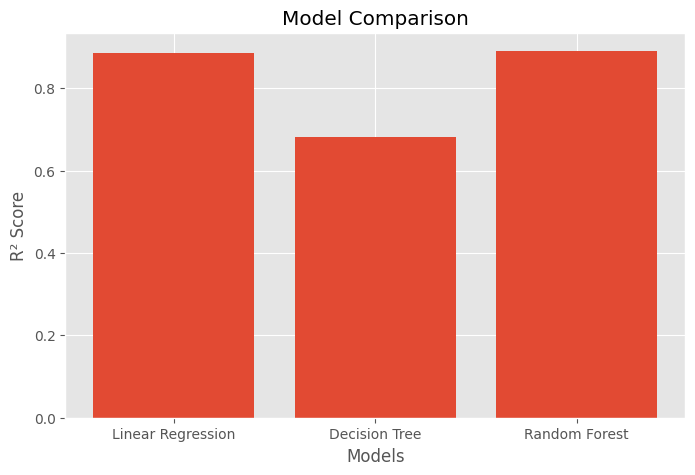

In [45]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["R2 Score"])

plt.title("Model Comparison")

plt.xlabel("Models")

plt.ylabel("R² Score")

plt.show()

In [46]:
from sklearn.model_selection import GridSearchCV
import joblib

In [47]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}


In [48]:
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

In [49]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_s

In [50]:
print("Best Parameters:")

grid_search.best_params_

Best Parameters:


{'max_depth': None,
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'n_estimators': 200}

In [51]:
best_model = grid_search.best_estimator_

In [52]:
best_predictions = best_model.predict(X_test)

In [53]:
print("Optimized Random Forest")

print("MAE:",
      mean_absolute_error(
          y_test,
          best_predictions
      ))

print("RMSE:",
      np.sqrt(mean_squared_error(
          y_test,
          best_predictions
      )))

print("R2 Score:",
      r2_score(
          y_test,
          best_predictions
      ))

Optimized Random Forest
MAE: 16719.284838763175
RMSE: 24065.503503059736
R2 Score: 0.8896527634979537


In [54]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
80,TotalLivingArea,0.458464
17,OverallQual,0.331592
30,BsmtQual,0.016689
46,GrLivArea,0.014745
34,BsmtFinSF1,0.013691
20,YearRemodAdd,0.011812
19,YearBuilt,0.011024
81,HouseAge,0.010200
62,GarageArea,0.009936
4,LotArea,0.008050


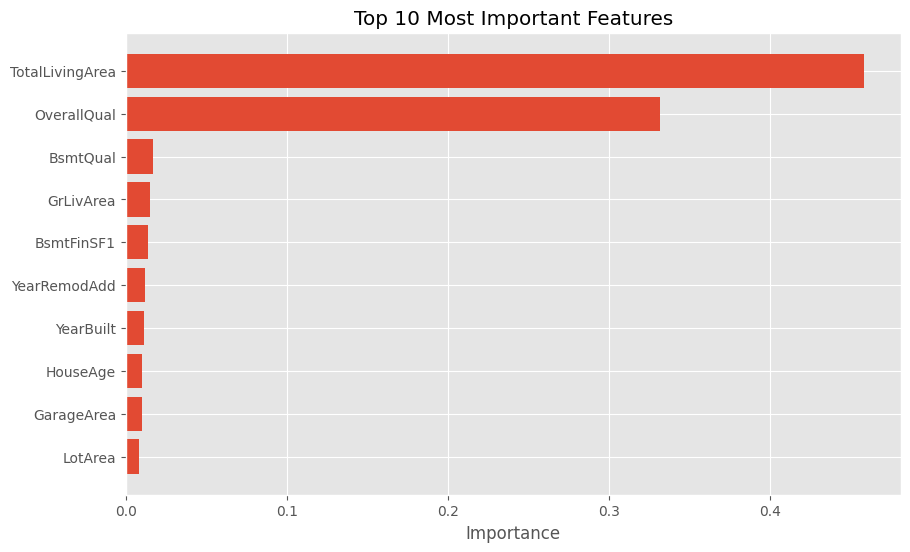

In [55]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:10],
    importance["Importance"][:10]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Most Important Features")

plt.xlabel("Importance")

plt.show()

In [56]:
import os

os.makedirs("../models", exist_ok=True)

In [57]:
joblib.dump(
    best_model,
    "../models/house_price_model.pkl"
)

print("Model Saved Successfully!")


Model Saved Successfully!


In [58]:
joblib.dump(
    X.columns.tolist(),
    "../models/model_features.pkl"
)

['../models/model_features.pkl']

In [59]:
df_clean.to_csv(
    "../data/final_clean_dataset.csv",
    index=False
)

In [60]:
final_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Optimized Random Forest"
    ],
    "R2 Score": [
        r2_score(y_test, linear_predictions),
        r2_score(y_test, decision_predictions),
        r2_score(y_test, forest_predictions),
        r2_score(y_test, best_predictions)
    ]
})

final_results

,Model,R2 Score
0,Linear Regression,0.885038
1,Decision Tree,0.682119
2,Random Forest,0.890273
3,Optimized Random Forest,0.889653
